In [1]:
import os
from mdagent import MDAgent

In [2]:
prompt13 = "Simulate trypsin (1TRN) for 1 ns at 300 K and compute SASA."
llm_var = "claude-3-opus-20240229"
tools = "all"
agent = MDAgent(agent_type="Structured", model=llm_var, top_k_tools=tools, use_memory=False)
print(llm_var)

claude-3-opus-20240229


In [3]:
agent.run(prompt13)

Thought: To simulate trypsin and compute SASA, I will need to:
1. Download the PDB file for trypsin (1TRN)
2. Set up and run a 1 ns simulation at 300 K 
3. Compute the solvent accessible surface area from the trajectory

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1TRN"
}
```PDB file found with this ID: 1TRN
Here are the steps to simulate trypsin (1TRN) for 1 ns at 300 K and compute the solvent accessible surface area (SASA):

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1TRN_190045",
    "forcefield_files": ["amber14/protein.ff14SB.xml", "amber14/tip3p.xml"],
    "system_params": {
      "nonbondedMethod": "PME", 
      "nonbondedCutoff": "1.0 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": "0.00001",
      "ewaldErrorTolerance": "0.0005",
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle", 
      "Temperature": "300 * kelvin"

({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n    OR a single \'Final Answer\' format.\n\n    Complete format:\n    Thought: (reflect on your progress and decide what to do next)\n    Action:\n    ```\n    {\n        "action": (the action name, it should be the name of a tool),\n        "action_input": (the input string for the action)\n    }\n    \'\'\'\n\n    OR\n\n    Final Answer: (the final response to the original input\n    question, once all steps are complete)\n\n    You are required to use the tools provided,\n    using the most specific tool\n    available for each action.\n    Your final answer should contain all information\n    necessary to answer the question and its subquestions.\n    Before you finish, reflect on your pro

In [4]:
registry = agent.path_registry
print(os.path.basename(registry.ckpt_dir))
paths_and_descriptions = registry.list_path_names_and_descriptions()
print("\n".join(paths_and_descriptions.split(",")))

ckpt_49
Files found in registry: 1TRN_190045: PDB file downloaded from RSCB
 PDBFile ID: 1TRN_190045
 1TRN_190114: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms Added and replaces nonstandard residues. 
 top_sim0_190125: Initial positions for simulation sim0_190125
 sim0_190125: Basic Simulation of Protein 1TRN_190114
 rec0_190132: Simulation trajectory for protein 1TRN_190114 and simulation sim0_190125
 rec1_190132: Simulation state log for protein 1TRN_190114 and simulation sim0_190125
 rec2_190132: Simulation pdb frames for protein 1TRN_190114 and simulation sim0_190125
 sasa_trypsin: Total SASA values for trypsin
 fig0_050444: Plot of SASA over time for trypsin


In [8]:
import re
import os
from IPython.display import Image

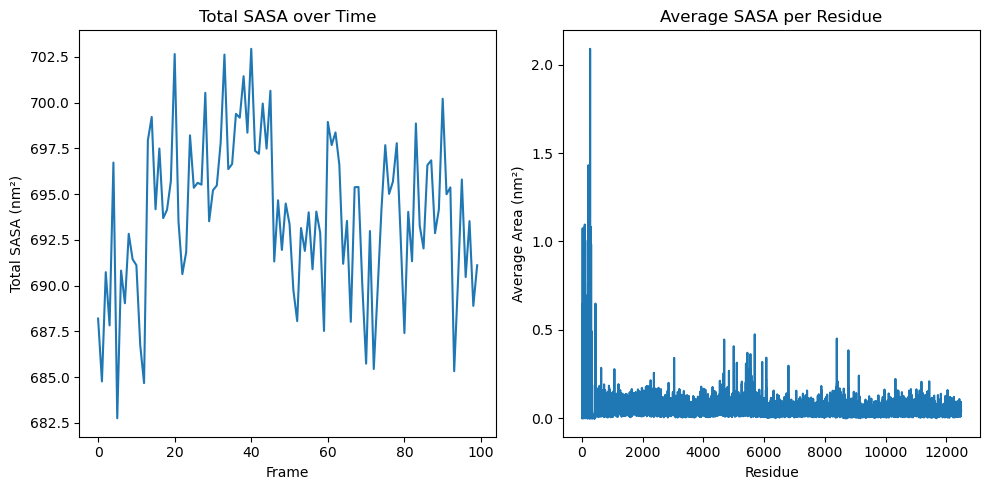

In [9]:
sasa = registry.get_mapped_path("fig0_050444")
assert os.path.exists(sasa), "Path does not exist"
Image(filename=sasa)